### EDA - Phân tích Univariate 

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [27]:
df_ = pd.read_csv("../../data/creditcard.csv")
df = df_.copy()
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [29]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

## Phân tích biến Amount

<Axes: xlabel='Class', ylabel='Amount'>

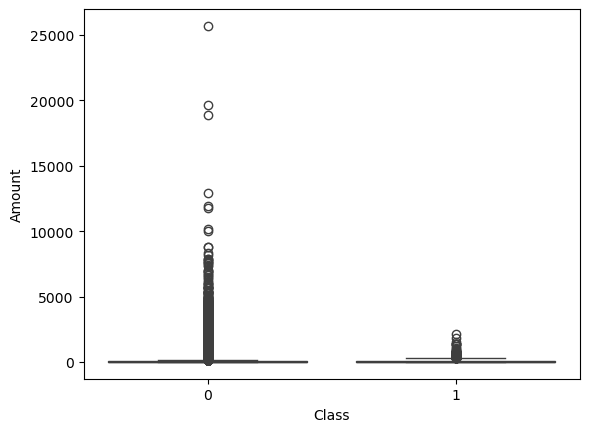

In [30]:
sns.boxplot(x="Class", y="Amount", data=df)


In [32]:
df.corr()['Class'].sort_values(ascending=False)


Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64

In [33]:
df['Amount'].skew()

16.977724453761024

Lệch phải mạnh 

In [34]:
df['_log_amount'] = np.log1p(df['Amount'])

Tạo cột _log_amount để giảm lệch, thu nhỏ khoảng giá trị, để xem phân phối tốt hơn, gần với phân phối chuẩn hơn, đặc biệt là dễ train model sau này hơn 

<Axes: xlabel='Class', ylabel='_log_amount'>

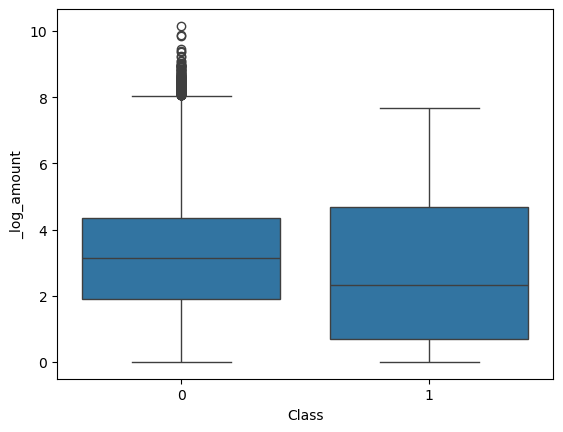

In [36]:
sns.boxplot(x="Class", y="_log_amount", data=df)

In [37]:
df['Amount'].kurt()

845.0926455465277

vì Amount lệch nên kurt rất cao là điều hiển nhiên <br>
ta nên xem của log amount vì đã giảm giá trị để dễ phân tích hơn

In [38]:
df['_log_amount'].kurt()

-0.6396966297263207

ta thấy giá trị đã phẳng hơn, điều này có nghĩa phân phối trở nên mượt hơn <br>
các outlier không còn quá nghiêm trọng

In [63]:
df["Amount_bin"] = pd.qcut(df["Amount"], q=10, duplicates="drop")
fraud_rate_by_bin = df.groupby("Amount_bin", observed=True)["Class"].mean()
print(fraud_rate_by_bin)

Amount_bin
(-0.001, 1.0]        0.005936
(1.0, 3.57]          0.001020
(3.57, 8.91]         0.001261
(8.91, 13.0]         0.000458
(13.0, 22.0]         0.000488
(22.0, 37.0]         0.000599
(37.0, 59.8]         0.000846
(59.8, 100.0]        0.001729
(100.0, 203.0]       0.001604
(203.0, 25691.16]    0.002987
Name: Class, dtype: float64


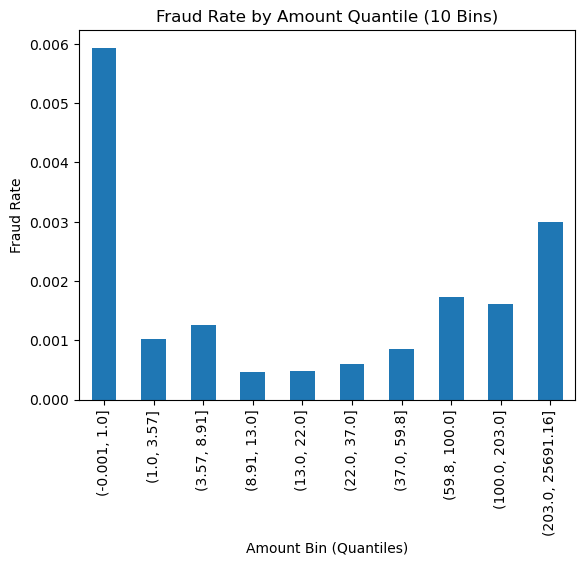

In [66]:
plt.figure()
fraud_rate_by_bin.plot(kind="bar")
plt.xlabel("Amount Bin (Quantiles)")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Amount Quantile (10 Bins)")
plt.show()

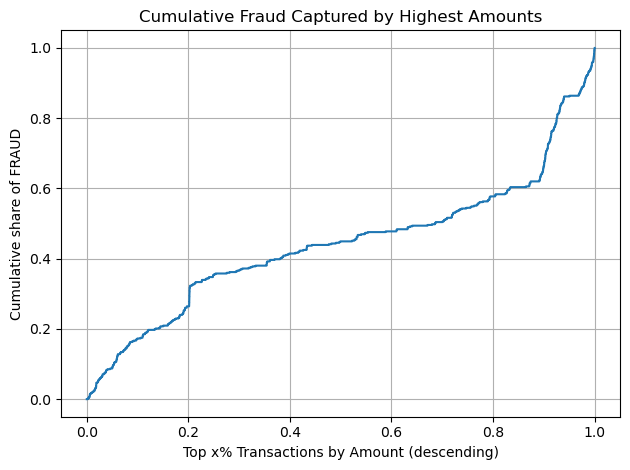

In [93]:
tmp = df[["Amount","Class"]].sort_values("Amount", ascending=False).reset_index(drop=True)
tmp["cum_tx"] = np.arange(1, len(tmp)+1) / len(tmp)
tmp["cum_fraud"] = tmp["Class"].cumsum() / tmp["Class"].sum()

plt.plot(tmp["cum_tx"], tmp["cum_fraud"])
plt.xlabel("Top x% Transactions by Amount (descending)")
plt.ylabel("Cumulative share of FRAUD")
plt.title("Cumulative Fraud Captured by Highest Amounts")
plt.grid(True)
plt.tight_layout()
plt.show()

## Phân tích biến Time

In [42]:
df['Time']

0              0.0
1              0.0
2              1.0
3              1.0
4              2.0
            ...   
284802    172786.0
284803    172787.0
284804    172788.0
284805    172788.0
284806    172792.0
Name: Time, Length: 284807, dtype: float64

biến time ở đây là thời gian kể từ giao dịch đầu tiên, nếu đưa vào model không có ý nghĩa. <br>
Các con số không nói lên được điều gì

In [44]:
df['Hour_from_start_mod24'] = ((df['Time'] // 3600) % 24).astype(int)

Tạo biến "hour from start mod 24" để biết giao dịch diễn ra vào giờ nào trong ngày <br> 
biến này thể hiện từ 00-23 giờ trong ngày

In [45]:
df['is_night_proxy'] = df['Hour_from_start_mod24'].isin([22,23,0,1,2,3,4,5]).astype(int)

Tạo biến "is night proxy", đây là biến nhị phân chỉ có giá trị 0- 1 <br>
biến này giúp ta thống kê được là các giao dịch gian lận có xảy diễn ra ban đêm hay không? <br>
1 = có ( từ 22h-5h) <br>
0 = không 

In [46]:
df['is_business_hours_proxy'] = df['Hour_from_start_mod24'].between(9,17).astype(int)

Tạo biến "is business hours proxy", để biết giao dịch gian lận có xảy ra giờ hành chính hay không? <br>
1= có ( từ 9-17h) <br>
0 = không

<h1> Tỉ lệ giao dịch gian lận theo giờ

In [48]:
df['Hour_from_start_mod24'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

In [49]:
df['Hour_from_start_mod24'].value_counts()

Hour_from_start_mod24
21    17703
18    17039
11    16856
20    16756
10    16598
14    16570
15    16461
16    16453
17    16166
9     15838
19    15649
22    15441
12    15420
13    15365
23    10938
8     10276
0      7695
7      7243
1      4220
6      4101
3      3492
2      3328
5      2990
4      2209
Name: count, dtype: int64

In [51]:
fraud_rate_by_hour = df.groupby("Hour_from_start_mod24")["Class"].mean()
print(fraud_rate_by_hour)

Hour_from_start_mod24
0     0.000780
1     0.002370
2     0.017127
3     0.004868
4     0.010412
5     0.003679
6     0.002195
7     0.003175
8     0.000876
9     0.001010
10    0.000482
11    0.003144
12    0.001102
13    0.001106
14    0.001388
15    0.001579
16    0.001337
17    0.001794
18    0.001937
19    0.001214
20    0.001074
21    0.000904
22    0.000583
23    0.001920
Name: Class, dtype: float64


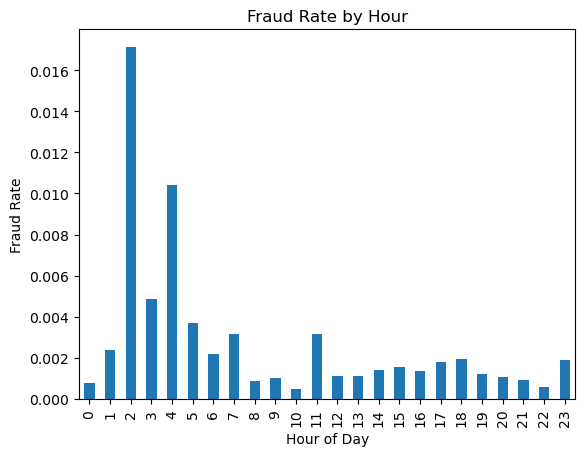

In [52]:
plt.figure()
fraud_rate_by_hour.plot(kind='bar')
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Hour")
plt.show()

2h và 4h có tỉ lệ giao dịch gian lận rất cao 

<h1>Số giao dịch mỗi giờ

In [53]:
transactions_per_hour = df.groupby("Hour_from_start_mod24").size()
print(transactions_per_hour)

Hour_from_start_mod24
0      7695
1      4220
2      3328
3      3492
4      2209
5      2990
6      4101
7      7243
8     10276
9     15838
10    16598
11    16856
12    15420
13    15365
14    16570
15    16461
16    16453
17    16166
18    17039
19    15649
20    16756
21    17703
22    15441
23    10938
dtype: int64


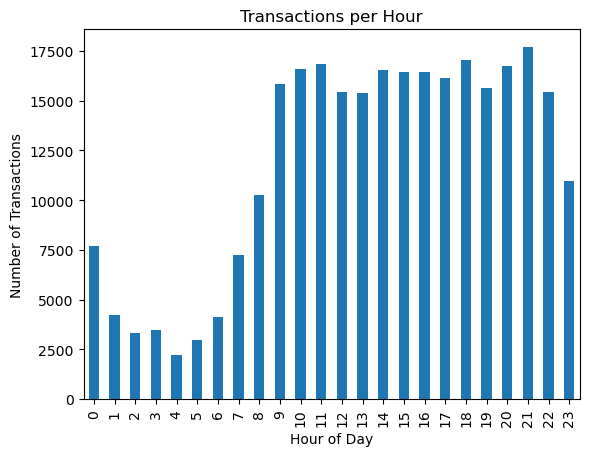

In [54]:
plt.figure()
transactions_per_hour.plot(kind='bar')
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.title("Transactions per Hour")
plt.show()

<h3>Time segment  (Morning / Afternoon / Evening / Night)

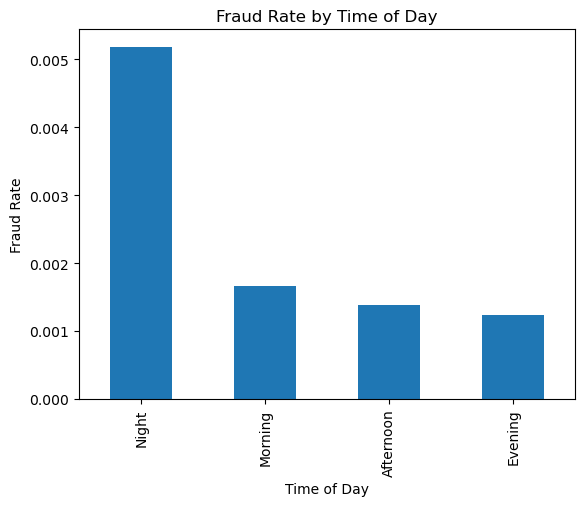

In [72]:
bins = [0, 6, 12, 18 ,24]
labels = ['Night', 'Morning', 'Afternoon', 'Evening']
df['Time_of_Day'] = pd.cut(df['Hour_from_start_mod24'], bins=bins, labels=labels, right=False)
fraud_rate_by_time_of_day = df.groupby("Time_of_Day", observed=True)["Class"].mean()

plt.figure()
fraud_rate_by_time_of_day.plot(kind='bar')
plt.xlabel("Time of Day")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Time of Day")
plt.show()

In [77]:
day_counts = df.groupby(["Time_of_Day", "Class"], observed=True).size().reset_index(name="Count")
day_total  = day_counts.groupby("Time_of_Day", observed=True)["Count"].transform("sum")
day_counts["Pct"] = day_counts["Count"] / day_total
print(day_counts)


  Time_of_Day  Class  Count       Pct
0       Night      0  23810  0.994819
1       Night      1    124  0.005181
2     Morning      0  70794  0.998336
3     Morning      1    118  0.001664
4   Afternoon      0  96301  0.998610
5   Afternoon      1    134  0.001390
6     Evening      0  93410  0.998760
7     Evening      1    116  0.001240


<h1>Correlation

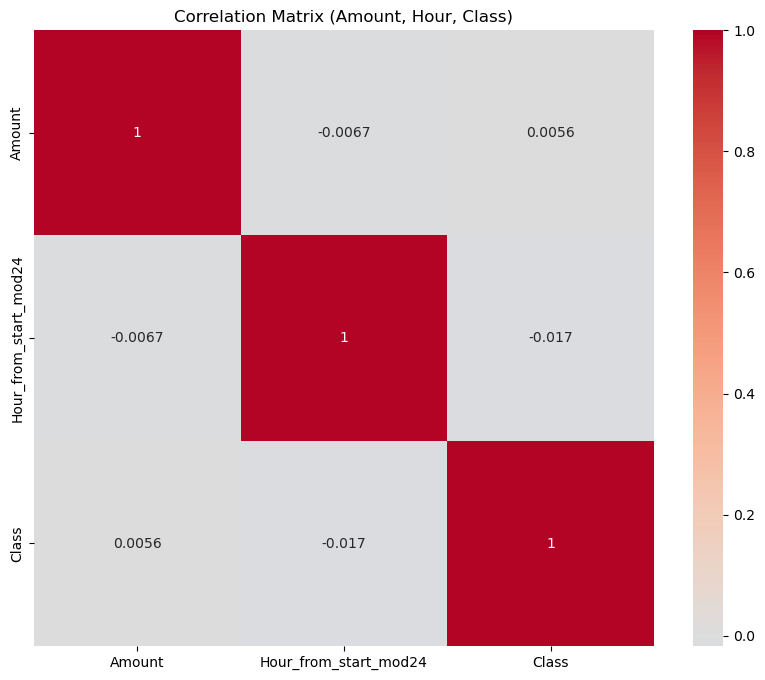

In [69]:
corr = df[["Amount", "Hour_from_start_mod24", "Class"]].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Amount, Hour, Class)")
plt.show()